In [ ]:
%matplotlib inline

import random
import torch
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt

In [ ]:
# 使用 w = [2, -3.4], b = 4.2 和噪声eps噪声项生成数据
# eps 服从均值为0的正态分布

def synthetic_data(w, b, num_example):
    """生成y = xw + b + noise"""
    X = torch.normal(0, 1, (num_example, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

In [ ]:
true_w = torch.tensor([2, -3.4])
true_b = torch.tensor(4.2)
features, labels = synthetic_data(true_w, true_b, 1000)
features, labels

(tensor([[ 0.4324,  1.2541],
         [-1.6339,  1.7035],
         [-0.4761, -1.3317],
         ...,
         [ 1.3887, -1.2264],
         [ 1.3808,  0.4051],
         [ 0.1173,  0.0359]]),
 tensor([[ 8.1550e-01],
         [-4.8649e+00],
         [ 7.7684e+00],
         [ 1.5900e+00],
         [ 1.0006e+01],
         [ 6.5050e+00],
         [ 5.9724e+00],
         [ 6.6935e+00],
         [-2.5626e+00],
         [ 6.4597e+00],
         [ 2.7965e+00],
         [ 2.4103e+00],
         [-2.5896e-01],
         [ 2.5168e+00],
         [ 9.5146e-01],
         [ 7.9064e-01],
         [ 2.2166e-01],
         [-6.0681e+00],
         [ 6.6822e+00],
         [ 9.1750e+00],
         [ 5.4122e+00],
         [ 5.1008e+00],
         [ 5.3997e+00],
         [ 6.7066e+00],
         [ 7.0508e+00],
         [ 3.6406e+00],
         [ 1.5391e+00],
         [-7.0312e+00],
         [-1.8886e+00],
         [ 3.0334e+00],
         [ 2.9478e+00],
         [ 8.9960e+00],
         [ 7.7058e+00],
         [ 5.6278e

In [ ]:
print(f"features: {features[0]}, label: {labels[0]}")
print(features.shape, labels.shape)

features: tensor([0.4324, 1.2541]), label: tensor([0.8155])
torch.Size([1000, 2]) torch.Size([1000, 1])


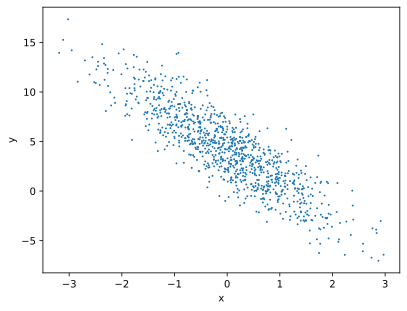

In [ ]:
# 绘制 features与labels之间的关系
fig, ax = plt.subplots()
backend_inline.set_matplotlib_formats('svg')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), s=1)
plt.show()


In [ ]:
# 读取数据集
def data_iter(batch_size, features, labels):
    """
    yeild 关键词返回一个generator, 
    它是一个generator对象，可以用next(gen_obj)
    访问下一批数据, 或者用for循环遍历访问
    """
    num_examples = len(features)
    indices = list(range(num_examples)) # index的复数
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [ ]:
for X, y in data_iter(10, features, labels):
    print(X, y, sep='\n')

tensor([[ 1.9150, -0.9596],
        [-0.7058, -0.1196],
        [ 1.0938,  1.0187],
        [-0.4347, -0.2113],
        [ 0.3261,  1.3631],
        [ 1.5828, -0.0590],
        [ 0.6058,  0.7378],
        [-1.5684, -0.1148],
        [ 0.5299,  1.0934],
        [ 0.1779,  0.6413]])
tensor([[11.3082],
        [ 3.1972],
        [ 2.9146],
        [ 4.0446],
        [ 0.2091],
        [ 7.5484],
        [ 2.9179],
        [ 1.4447],
        [ 1.5391],
        [ 2.3667]])
tensor([[ 0.0792, -1.1888],
        [-0.1038,  0.8412],
        [ 1.1611, -0.3107],
        [ 0.3999, -0.9054],
        [ 0.8340, -0.4627],
        [ 0.7818,  0.4760],
        [-0.9783, -0.5146],
        [ 0.1275,  0.1109],
        [ 1.5481,  0.5391],
        [ 1.0063,  0.6887]])
tensor([[8.3925],
        [1.1419],
        [7.5864],
        [8.0805],
        [7.4286],
        [4.1421],
        [3.9859],
        [4.0539],
        [5.4682],
        [3.8651]])
tensor([[ 1.2419,  0.5084],
        [ 0.6544,  0.9333],
        [ 

In [ ]:
# 初始化模型参数

w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)
w, b

(tensor([[-0.0036],
         [ 0.0018]], requires_grad=True),
 tensor([0.], requires_grad=True))

In [ ]:
# 定义模型 
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b

In [ ]:
# 定义损失函数
def squared_loss(y_hat, y):
    """均方损失"""
    # return (y_hat - y) ** 2 / 2
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2


In [ ]:
def sgd(params, lr, batch_size):
    """
    小批量随机梯度下降, 
    Stochastic gradient descent
    """

    with torch.no_grad(): # 这里不会构建计算图
        # with 关键字表明代码块执行完成后释放资源
        for params in params:
            params -= lr * params.grad / batch_size
            params.grad.zero_()

In [ ]:
lr = 0.01
num_epochs = 10
batch_size = 10
net = linreg
loss = squared_loss
loss_list = []
# 模型参数
# w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
# b = torch.zeros(1, requires_grad=True)
# 模型参数, 初始化为0会怎么样？
# w = torch.zeros((2, 1), requires_grad=True)
# b = torch.zeros(1, requires_grad=True)
w, b

(tensor([[-0.0036],
         [ 0.0018]], requires_grad=True),
 tensor([0.], requires_grad=True))

In [ ]:
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        # print(X, y, sep='\n')
        l = loss(net(X, w, b), y)
        l.sum().backward()
        loss_list.append(l.detach().mean()) 
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f"epoch {epoch + 1}, loss {train_l.mean().float()}")

epoch 1, loss 2.175450086593628
epoch 2, loss 0.28283801674842834
epoch 3, loss 0.03728465363383293
epoch 4, loss 0.0050099617801606655
epoch 5, loss 0.0007148059085011482
epoch 6, loss 0.0001398143358528614
epoch 7, loss 6.126496737124398e-05
epoch 8, loss 5.0297378038521856e-05
epoch 9, loss 4.883375731878914e-05
epoch 10, loss 4.860420449404046e-05


In [ ]:
# 参数与真值的误差
print(f"w的误差：{true_w - w.reshape(true_w.shape)}")
print(f"b的误差：{true_b - b}")

w的误差：tensor([-1.3733e-04, -8.7976e-05], grad_fn=<SubBackward0>)
b的误差：tensor([5.6744e-05], grad_fn=<SubBackward0>)


1000 1000


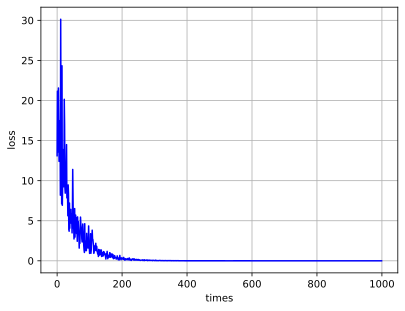

In [ ]:
loss_list
times = [i for i in range(num_epochs * int(len(features) / batch_size))]
print(len(loss_list), len(times))
fig, ax = plt.subplots()
ax.set_xlabel("times")
ax.set_ylabel("loss")
# ax.set_xscale("log")
ax.grid()
ax.plot(times, loss_list, c='blue')
plt.show()